#Семинар 11: Современный градиентный бустинг.

Раньше для использования градиентного бустинга необходимо было самостоятельно имплементировать алгоритм. Этим занимались и в крупных корпорациях, которые использовали машинное обучение в своих задачах (например, Microsoft и Яндекс). Некоторые из этих модифицированных имплементаций вышли в open source и чаще всего именно они используются на практике. В настоящее время наиболее популярные следующие реализации:
* XGboost + подбор гиперпараметров
* CatBoost + SHAP
* LightGBM

!["История"](https://github.com/hse-ds/iad-intro-ds/blob/master/2023/seminars/sem15_boosting_part2/bst.png?raw=1)

## 1. XGboost + подбор гиперпараметров

Код по xgboost основан на статье https://www.analyticsvidhya.com/blog/2016/03/complete-guide-parameter-tuning-xgboost-with-codes-python/

Основные особенности xgboost:
* базовый алгоритм приближает направление, посчитанное с учетом второй производной функции потерь

* функционал регуляризуется – добавляются штрафы за количество листьев и за норму коэффициентов

* при построении дерева используется критерий информативности, зависящий от оптимального вектора сдвига

* критерий останова при обучении дерева также зависит от оптимального сдвига

Почитать подробнее тут: https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture10-ensembles.pdf

In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

import xgboost as xgb
from xgboost.sklearn import XGBClassifier

Рассмотрим применение данной реализации на примере задачи классификации: по различным характеристикам клиента попытаемся определить, выплатит он долг или нет.

In [ ]:
X_train = pd.read_csv("https://raw.githubusercontent.com/hse-ds/iad-intro-ds/master/2023/seminars/sem15_boosting_part2/train_small.csv")
X_test = pd.read_csv("https://raw.githubusercontent.com/hse-ds/iad-intro-ds/master/2023/seminars/sem15_boosting_part2/test_small.csv")
len(X_train), len(X_test)

(24365, 10443)

In [ ]:
# Либо так:

# X_train = pd.read_csv("https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/seminars/seminar11/train_small.csv")
# X_test = pd.read_csv("https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/seminars/seminar11/test_small.csv")
# len(X_train), len(X_test)

In [ ]:
X_train.head()

,Existing_EMI,Loan_Amount_Applied,Loan_Tenure_Applied,Monthly_Income,Var4,Var5,Age,EMI_Loan_Submitted_Missing,Interest_Rate_Missing,Loan_Amount_Submitted_Missing,...,Var2_4,Var2_5,Var2_6,Mobile_Verified_0,Mobile_Verified_1,Source_0,Source_1,Source_2,Disbursed,ID
0,0.0,250000.0,5.0,23200,2,3,28,1,1,0,...,0,0,0,0,1,0,1,0,0.0,8161
1,0.0,0.0,0.0,25000,0,0,33,1,1,1,...,0,0,1,0,1,1,0,0,0.0,77530
2,0.0,0.0,0.0,95000,3,7,39,1,1,0,...,0,0,1,0,1,1,0,0,0.0,80633
3,0.0,0.0,0.0,29880,5,3,28,0,0,0,...,0,0,0,0,1,0,1,0,0.0,45059
4,4500.0,100000.0,3.0,30000,5,10,26,0,0,0,...,0,0,1,0,1,1,0,0,0.0,54857


Вспомним, что для того, чтобы бустинг показал хорошее качество и не переобучился, необходимо аккуратно подобрать его гиперпараметры.

Алгоритм подбора гиперпараметров может быть следующим:

* Выбираем относительно большую learning_rate ($ \eta \in [0.05, 0.3]$), подбираем оптимальное число деревьев для выбранного $ \eta $

* Настраиваем параметры деревьев, начиная с самых значимых (max_depth, min_child_weight, gamma, subsample, colsample_bytree)

* Настраиваем регуляризации ($ \lambda, \alpha $)

* Уменьшаем learning_rate, пропорционально увеличиваем число деревьев

In [ ]:
model_xgb = XGBClassifier(
    learning_rate=0.1,
    n_estimators=150,
    objective="binary:logistic",
    nthread=-1,
    scale_pos_weight=1,
    seed=27,
    eval_metric="auc",
)

In [ ]:
target = "Disbursed"
IDcol = "ID"

In [ ]:
X_train["Disbursed"].value_counts(), len(X_train)

(Disbursed
 0.0    23999
 1.0      366
 Name: count, dtype: int64,
 24365)

Создадим функцию для моделирования и кросс-валидации

Эта функция делает следующее:
1. обучает модель
2. вычисляет accuracy на тренировочной выборке
3. вычисляет AUC на тренировочной выборке
4. вычисляет AUC на тестовой выборке
5. обновляет n_estimators с помощью встроенной в пакет xgboost функции cv
6. строит диаграмму Feature Importance

In [ ]:
from sklearn import metrics

def modelfit(
    alg,
    dtrain,
    dtest,
    predictors,
    useTrainCV=True,
    cv_folds=5,
    early_stopping_rounds=50,
):
    if useTrainCV:
        xgb_param = alg.get_xgb_params()
        xgtrain = xgb.DMatrix(dtrain[predictors].values, label=dtrain[target].values)
        xgtest = xgb.DMatrix(dtest[predictors].values)
        cvresult = xgb.cv(
            xgb_param,
            xgtrain,
            num_boost_round=alg.get_params()["n_estimators"],
            nfold=cv_folds,
            metrics="auc",
            early_stopping_rounds=early_stopping_rounds,
        )
        alg.set_params(n_estimators=cvresult.shape[0])

    # Fit the algorithm on the data
    alg.fit(dtrain[predictors], dtrain["Disbursed"])

    # Predict training set:
    dtrain_predictions = alg.predict(dtrain[predictors])
    dtrain_predprob = alg.predict_proba(dtrain[predictors])[:, 1]

    # Print model report:
    print("\nModel Report")
    print(
        "Accuracy : %.4g"
        % metrics.accuracy_score(dtrain["Disbursed"].values, dtrain_predictions)
    )
    print(
        "AUC Score (Train): %f"
        % metrics.roc_auc_score(dtrain["Disbursed"], dtrain_predprob)
    )

    # Predict on testing data:
    dtest["predprob"] = alg.predict_proba(dtest[predictors])[:, 1]
    print(
        "AUC Score (Test): %f"
        % metrics.roc_auc_score(dtest["Disbursed"], dtest["predprob"])
    )

    feat_imp = pd.Series(alg.get_booster().get_fscore()).sort_values(ascending=False)
    feat_imp.plot(kind="bar", title="Feature Importances")
    plt.ylabel("Feature Importance Score")

Начинаем последовательный подбор параметров при большом learning_rate


Model Report
Accuracy : 0.985
AUC Score (Train): 0.914990
AUC Score (Test): 0.826214


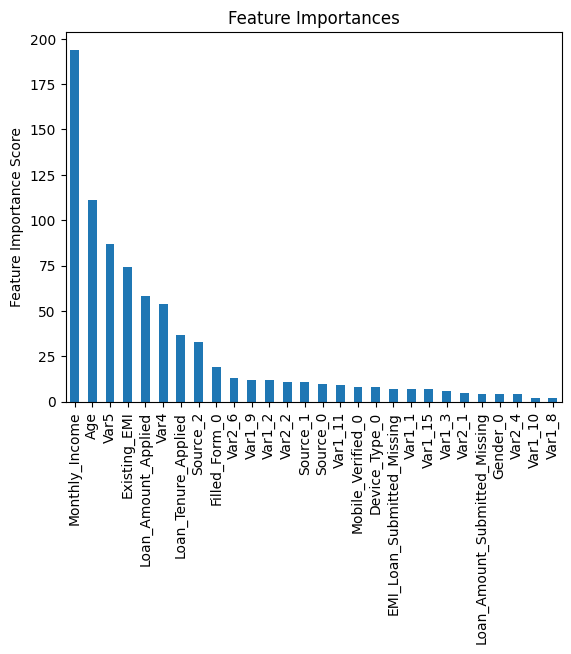

In [ ]:
predictors = [x for x in X_train.columns if x not in [target, IDcol]]

modelfit(model_xgb, X_train, X_test, predictors)

Перебираем max_depth и min_child_weight по сетке.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_test1 = {"max_depth": range(2, 7, 2), "min_child_weight": range(1, 6, 2)}

gsearch1 = GridSearchCV(
    estimator=model_xgb, param_grid=param_test1, scoring="roc_auc", n_jobs=-1, cv=5
)

gsearch1.fit(X_train[predictors], X_train[target])

gsearch1.best_params_, gsearch1.best_score_

({'max_depth': 6, 'min_child_weight': 5}, np.float64(0.8243835436796025))

Уточняем предсказание

In [ ]:
param_test2 = {"max_depth": [3, 4, 5], "min_child_weight": [2, 3, 4]}

gsearch2 = GridSearchCV(
    estimator=model_xgb, param_grid=param_test2, scoring="roc_auc", n_jobs=-1, cv=5
)

gsearch2.fit(X_train[predictors], X_train[target])
gsearch2.best_params_, gsearch2.best_score_

({'max_depth': 5, 'min_child_weight': 3}, np.float64(0.8268420365935718))

Зафиксируем найденный max_depth и min_child_weight

In [ ]:
model_xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'auc',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 37,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 1,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'nthread': -1,
 'seed': 27}

In [ ]:
model_xgb.max_depth = 5
model_xgb.min_child_weight = 3

In [ ]:
model_xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'auc',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': 3,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 37,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 1,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'nthread': -1,
 'seed': 27}

Мы подобрали max_depth и min_child_weight - дальше будем использовать подобранные значения параметров. Подберите по сетке параметр gamma на отрезке от 0 до 1.

In [ ]:
param_test3 = {
    'gamma': np.linspace(0, 1, 10) # Ваш код сюда :)
}

gsearch3b = GridSearchCV(
    estimator=model_xgb, param_grid=param_test3, scoring="roc_auc", n_jobs=-1, cv=5
) # Ваш код сюда :)

gsearch3b.fit(X_train[predictors], X_train[target]).fit(X_train[predictors], X_train[target])

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='auc', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=No...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=5,
                                     max_leaves=None, min_child_weight=3,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=37,
                                     n_jobs=None, nthread=-1, ...),
             n_jobs=-1,
             param_grid={'gamma': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])},
             scoring='roc_auc')

In [ ]:
gsearch3b.best_params_, gsearch3b.best_score_

({'gamma': np.float64(0.8888888888888888)}, np.float64(0.8271071540059471))

Установите в качестве параметра алгоритма подобранyю gamma и посмотрите как изменилось качество.

In [ ]:
model_xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'auc',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': 3,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 37,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 1,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'nthread': -1,
 'seed': 27}

In [ ]:
model_xgb.gamma = 0.9 # Ваш код сюда :)

In [ ]:
model_xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'auc',
 'feature_types': None,
 'feature_weights': None,
 'gamma': 0.9,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': 3,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 37,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 1,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'nthread': -1,
 'seed': 27}


Model Report
Accuracy : 0.985
AUC Score (Train): 0.889654
AUC Score (Test): 0.829251


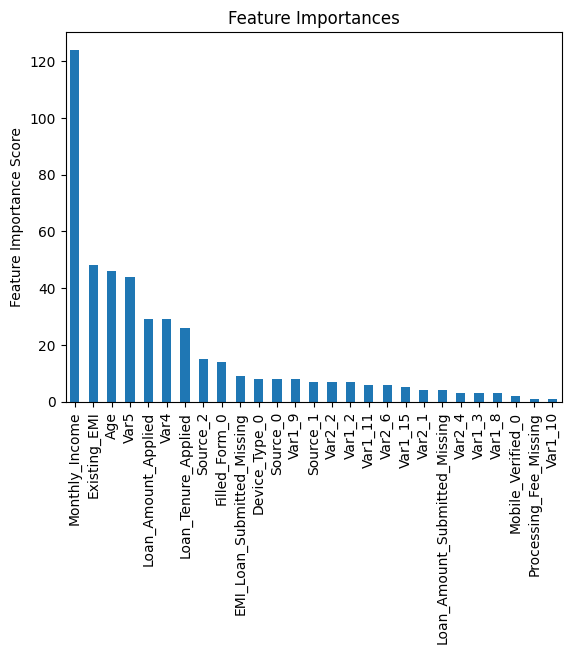

In [ ]:
predictors = [x for x in X_train.columns if x not in [target, IDcol]]

modelfit(model_xgb, X_train, X_test, predictors)

Подберите по сетке параметры subsample и colsample_bytree. Используйте значения этих параметров: [0.6, 0.7, 0.8, 0.9, 1.]

In [ ]:
param_test4 = {"subsample": [0.6, 0.7, 0.8, 0.9, 1.], "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.]} # Ваш код сюда :)

gsearch4 = GridSearchCV(
    estimator=model_xgb, param_grid=param_test4, scoring="roc_auc", n_jobs=-1, cv=5
) # Ваш код сюда :)

gsearch4.fit(X_train[predictors], X_train[target])
gsearch4.best_params_, gsearch4.best_score_

({'colsample_bytree': 0.9, 'subsample': 0.8}, np.float64(0.8276751827272856))

In [ ]:
model_xgb.subsample = 0.8
model_xgb.colsample_bytree = 0.9

In [ ]:
model_xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.9,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'auc',
 'feature_types': None,
 'feature_weights': None,
 'gamma': 0.9,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': 3,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 37,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 1,
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'nthread': -1,
 'seed': 27}

Подберите параметр регуляризации reg_alpha. Попробуйте [1e-5, 1e-2, 0.1, 1, 100]

In [ ]:
param_test5 = {"reg_alpha": [1e-5, 1e-2, 0.1, 1, 100]} # Ваш код сюда :)

gsearch5 = GridSearchCV(
    estimator=model_xgb, param_grid=param_test5, scoring="roc_auc", n_jobs=-1, cv=5
) # Ваш код сюда :)

gsearch5.fit(X_train[predictors], X_train[target])
gsearch5.best_params_, gsearch5.best_score_

({'reg_alpha': 1e-05}, np.float64(0.8276751827272857))

In [ ]:
model_xgb.reg_alpha = 1e-05 # Ваш код сюда :)

In [ ]:
model_xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.9,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'auc',
 'feature_types': None,
 'feature_weights': None,
 'gamma': 0.9,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': 3,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 37,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': 1e-05,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 1,
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'nthread': -1,
 'seed': 27}

Запустите обучение и предсказание на найденных параметрах и посмотрите на качество.


Model Report
Accuracy : 0.985
AUC Score (Train): 0.890363
AUC Score (Test): 0.831517


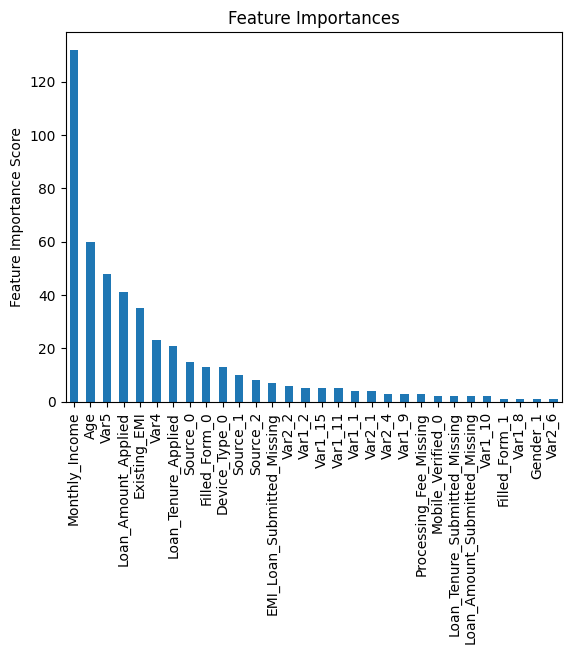

In [ ]:
modelfit(model_xgb, X_train, X_test, predictors)

Уменьшите learning_rate до 0.01 и пропорционально увеличьте число деревьев. Все подобранные параметры остаются такими же. Обучите модель и сделайте предсказание. Посмотрите на качество.

In [ ]:
model_xgb.learning_rate = 0.01 # Ваш код сюда :)
model_xgb.n_estimators = 1500 # Ваш код сюда :)

In [ ]:
model_xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.9,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'auc',
 'feature_types': None,
 'feature_weights': None,
 'gamma': 0.9,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.01,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': 3,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 1500,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': 1e-05,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 1,
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'nthread': -1,
 'seed': 27}


Model Report
Accuracy : 0.985
AUC Score (Train): 0.907435
AUC Score (Test): 0.835484


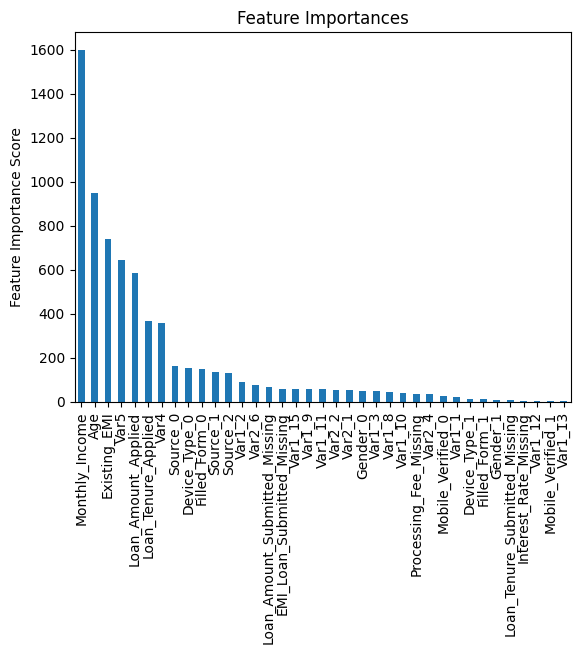

In [ ]:
modelfit(model_xgb, X_train, X_test, predictors)

## 2. CatBoost

Ноутбук из официальной документации здесь: https://github.com/catboost/tutorials/blob/master/classification/classification_tutorial.ipynb

Особенности катбуста:

* используются симметричные деревья решений

* для кодирования категориальных признаков используется большой набор методов

* динамический бустинг

Благодаря использованию симметричных деревьев и динамическому бустингу катбуст гораздо более устойчив к переобучению, чем другие имплементации градиентного бустинга. Поэтому он показывает хорошее качество даже при дефолтных параметрах.

Посмотреть видео про катбуст: https://yandex.ru/video/preview/?filmId=10919886479285152550&from=tabbar&text=catboost+анна+вероника

Устанавливаем библиотеки

In [ ]:
!pip install -q --upgrade catboost shap numpy

# В Colab не нужно:
# !pip install -q --upgrade ipywidgets
# !pip install -q sklearn
# !jupyter nbextension enable --py widgetsnbextension

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [ ]:
np.set_printoptions(precision=4)

import catboost
from catboost import *
from catboost import datasets

Считываем данные. Данные содержат только категориальные признаки, причем с большим количеством категорий. Признаки - закодированные характеристики сотрудника и некоторого ресурса, целевая переменная - есть ли у сотрудника доступ к ресурсу.

In [ ]:
(train_df, test_df) = catboost.datasets.amazon()

In [ ]:
train_df.head()

,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


Готовим данные

In [ ]:
y = train_df.ACTION
X = train_df.drop("ACTION", axis=1)

Создаем список категориальных фичей

In [ ]:
cat_features = list(range(0, X.shape[1]))
print(cat_features)

[0, 1, 2, 3, 4, 5, 6, 7, 8]


Смотрим на соотношение классов

In [ ]:
print("Labels: {}".format(set(y)))
print("Zero count = {}, One count = {}".format(len(y) - sum(y), sum(y)))

Labels: {0, 1}
Zero count = 1897, One count = 30872


В catboost используется абстракция Pool - это объект, который содержит матрицу объект-признак X, вектор ответов, список номеров колонок с категориальными признаками.

In [ ]:
pool1 = Pool(data=X, label=y, cat_features=cat_features)

pool2 = Pool(data=X, cat_features=cat_features)

# Fastest way to create a Pool is to create it from numpy matrix.
# This way should be used if you want fast predictions
# or fastest way to load the data in python.

X_prepared = X.values.astype(str).astype(object)
# For FeaturesData class categorial features must have type str

pool3 = Pool(
    data=FeaturesData(cat_feature_data=X_prepared, cat_feature_names=list(X)),
    label=y.values,
)

print("Dataset shape")
print(
    "dataset 1:"
    + str(pool1.shape)
    + "\ndataset 2:"
    + str(pool2.shape)
    + "\ndataset 3: "
    + str(pool3.shape)
)

print("\n")
print("Column names")
print("dataset 1:")
print(pool1.get_feature_names())
print("\ndataset 2:")
print(pool2.get_feature_names())
print("\ndataset 3:")
print(pool3.get_feature_names())

Dataset shape
dataset 1:(32769, 9)
dataset 2:(32769, 9)
dataset 3: (32769, 9)


Column names
dataset 1:
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']

dataset 2:
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']

dataset 3:
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']


Разбиваем данные на train и validation

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, train_size=0.8, random_state=42
)

Выбираем функцию потерь

Для бинарной классификации можем использовать:

* `Logloss`

* `CrossEntropy`

In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(iterations=10, learning_rate=0.1)
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
    verbose=False,
)
print("Model is fitted: " + str(model.is_fitted()))
print("Model params:")
print(model.get_params())

Model is fitted: True
Model params:
{'iterations': 10, 'learning_rate': 0.1}


Печать результатов

In [ ]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
)

0:	learn: 0.6189879	test: 0.6185816	best: 0.6185816 (0)	total: 39.8ms	remaining: 358ms
1:	learn: 0.5585149	test: 0.5574616	best: 0.5574616 (1)	total: 80.5ms	remaining: 322ms
2:	learn: 0.5082799	test: 0.5069499	best: 0.5069499 (2)	total: 103ms	remaining: 240ms
3:	learn: 0.4660897	test: 0.4643558	best: 0.4643558 (3)	total: 135ms	remaining: 203ms
4:	learn: 0.4304632	test: 0.4282709	best: 0.4282709 (4)	total: 172ms	remaining: 172ms
5:	learn: 0.4002849	test: 0.3979354	best: 0.3979354 (5)	total: 214ms	remaining: 143ms
6:	learn: 0.3745697	test: 0.3720454	best: 0.3720454 (6)	total: 232ms	remaining: 99.6ms
7:	learn: 0.3525686	test: 0.3498882	best: 0.3498882 (7)	total: 249ms	remaining: 62.3ms
8:	learn: 0.3336944	test: 0.3308677	best: 0.3308677 (8)	total: 270ms	remaining: 30ms
9:	learn: 0.3174817	test: 0.3145131	best: 0.3145131 (9)	total: 285ms	remaining: 0us

bestTest = 0.3145131058
bestIteration = 9



CatBoostClassifier(iterations=10, learning_rate=0.1)

Визуализация метрик

In [ ]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
    verbose=False,
    plot=True,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(iterations=10, learning_rate=0.1)

Сравнение моделей

In [ ]:
model1 = CatBoostClassifier(
    learning_rate=0.1, iterations=100, random_seed=0, train_dir="learning_rate_0.1"
)

model2 = CatBoostClassifier(
    learning_rate=0.07, iterations=100, random_seed=0, train_dir="learning_rate_0.07"
)
model1.fit(
    X_train,
    y_train,
    eval_set=(X_validation, y_validation),
    cat_features=cat_features,
    verbose=False,
)
model2.fit(
    X_train,
    y_train,
    eval_set=(X_validation, y_validation),
    cat_features=cat_features,
    verbose=False,
)

CatBoostClassifier(iterations=100, learning_rate=0.07, random_seed=0, train_dir='learning_rate_0.07')

In [ ]:
# from google.colab import output
# output.enable_custom_widget_manager()

In [ ]:
# from google.colab import output
# output.disable_custom_widget_manager()

In [ ]:
# from catboost import MetricVisualizer

# MetricVisualizer(["learning_rate_0.1", "learning_rate_0.07"]).start()

Оптимальное количество деревьев

In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=100,
    random_seed=63,
    learning_rate=0.5,
    #     use_best_model=False
)
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
    verbose=False,
    plot=True,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(iterations=100, learning_rate=0.5, random_seed=63)

In [ ]:
print("Tree count: " + str(model.tree_count_))

Tree count: 92


Кросс-валидация

In [ ]:
from catboost import cv

params = {}
params["loss_function"] = "Logloss"
params["iterations"] = 80
params["custom_loss"] = "AUC"
params["random_seed"] = 63
params["learning_rate"] = 0.5

cv_data = cv(
    params=params,
    pool=Pool(X, label=y, cat_features=cat_features),
    fold_count=5,
    shuffle=True,
    partition_random_seed=0,
    plot=True,
    stratified=False,
    verbose=False,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]

bestTest = 0.1695893693
bestIteration = 38

Training on fold [1/5]

bestTest = 0.164632916
bestIteration = 48

Training on fold [2/5]

bestTest = 0.15425211
bestIteration = 35

Training on fold [3/5]

bestTest = 0.1433537051
bestIteration = 55

Training on fold [4/5]

bestTest = 0.1560519524
bestIteration = 55



In [ ]:
cv_data.head()

,iterations,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std,test-AUC-mean,test-AUC-std
0,0,0.302367,0.004317,0.302196,0.004517,0.513577,0.030360
1,1,0.227370,0.007679,0.228497,0.005126,0.642263,0.048004
2,2,0.190856,0.006917,0.196796,0.003999,0.791709,0.011361
3,3,0.178884,0.007455,0.186682,0.003242,0.813889,0.009362
4,4,0.172286,0.007957,0.181380,0.002135,0.826529,0.005319


In [ ]:
best_value = np.min(cv_data["test-Logloss-mean"])
best_iter = np.argmin(cv_data["test-Logloss-mean"])

print(
    "Best validation LogLoss score, not stratified: {:.4f}±{:.4f} on step {}".format(
        best_value, cv_data["test-Logloss-std"][best_iter], best_iter
    )
)

Best validation LogLoss score, not stratified: 0.1582±0.0102 on step 53


Детектор переобучения

In [ ]:
model_with_early_stop = CatBoostClassifier(
    iterations=200, random_seed=63, learning_rate=0.5, early_stopping_rounds=20
)
model_with_early_stop.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
    verbose=False,
    plot=True,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(early_stopping_rounds=20, iterations=200, learning_rate=0.5, random_seed=63)

In [ ]:
print(model_with_early_stop.tree_count_)

21


In [ ]:
model_with_early_stop = CatBoostClassifier(
    eval_metric="AUC",
    iterations=200,
    random_seed=63,
    learning_rate=0.5,
    early_stopping_rounds=20,
)
model_with_early_stop.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
    verbose=False,
    plot=True,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(early_stopping_rounds=20, eval_metric='AUC', iterations=200, learning_rate=0.5, random_seed=63)

In [ ]:
print(model_with_early_stop.tree_count_)

52


Вычисление метрик качества и выбор порога принятия решения

In [ ]:
model = CatBoostClassifier(
    random_seed=63,
    iterations=200,
    learning_rate=0.03,
)
model.fit(X_train, y_train, cat_features=cat_features, verbose=False, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(iterations=200, learning_rate=0.03, random_seed=63)

![](https://habrastorage.org/webt/y4/1q/yq/y41qyqfm9mcerp2ziys48phpjia.png)

In [ ]:
import sklearn
from catboost.utils import get_roc_curve
from sklearn import metrics

eval_pool = Pool(X_validation, y_validation, cat_features=cat_features)
curve = get_roc_curve(model, eval_pool)
(fpr, tpr, thresholds) = curve
roc_auc = sklearn.metrics.auc(fpr, tpr)

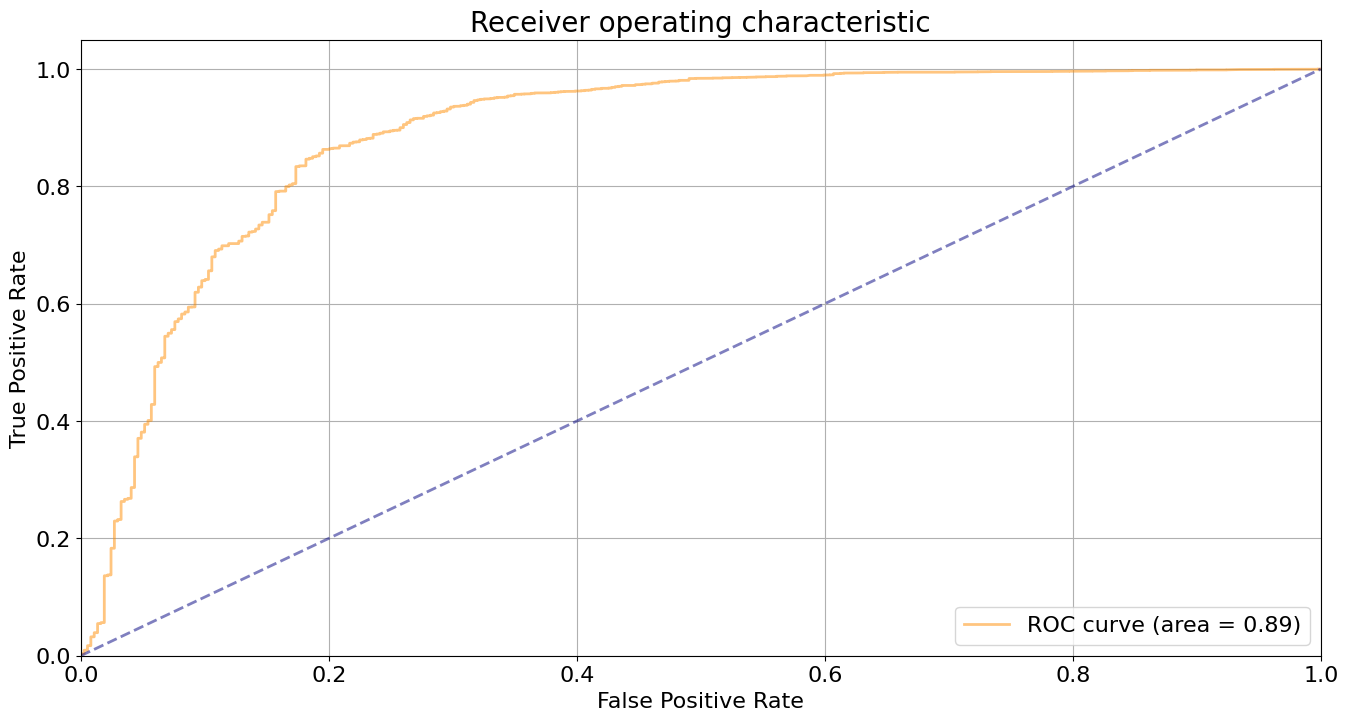

In [ ]:
plt.figure(figsize=(16, 8))
lw = 2

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
    alpha=0.5,
)

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--", alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)
plt.title("Receiver operating characteristic", fontsize=20)
plt.legend(loc="lower right", fontsize=16)
plt.show()

In [ ]:
from catboost.utils import get_fnr_curve, get_fpr_curve

(thresholds, fpr) = get_fpr_curve(curve=curve)
(thresholds, fnr) = get_fnr_curve(curve=curve)

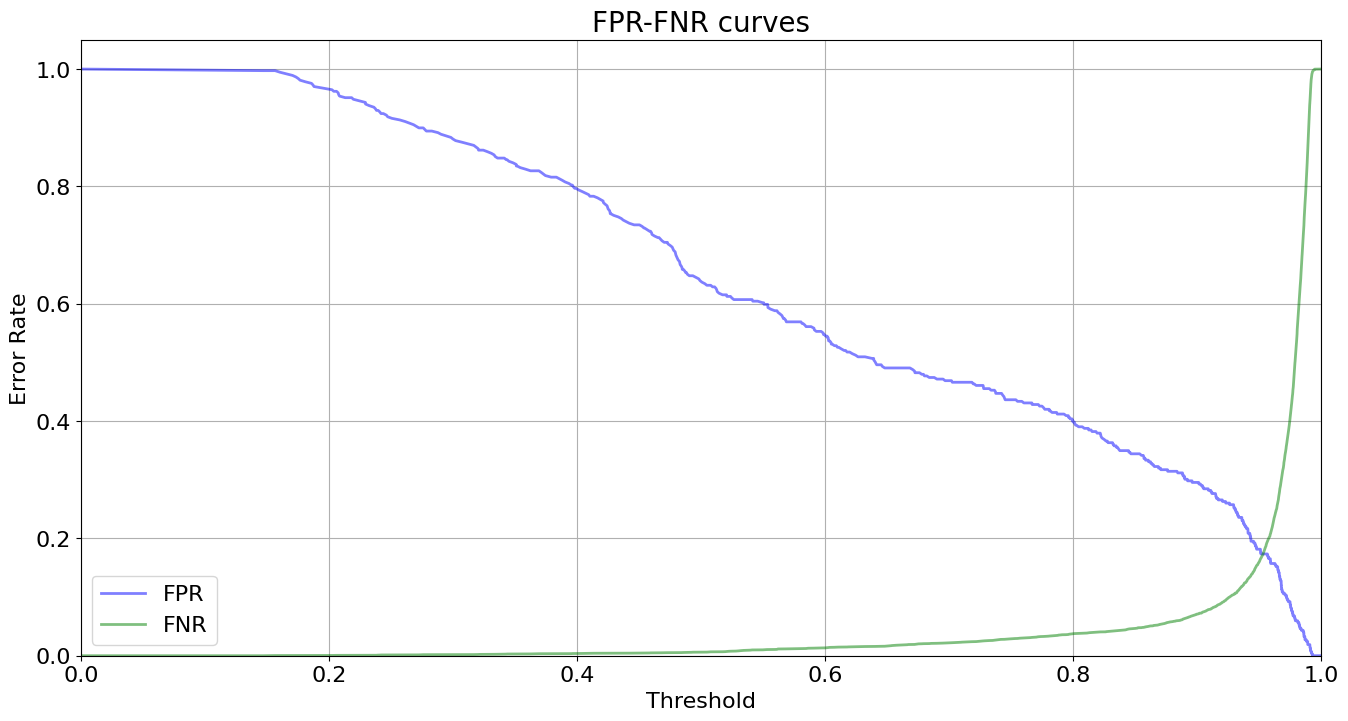

In [ ]:
plt.figure(figsize=(16, 8))
lw = 2

plt.plot(thresholds, fpr, color="blue", lw=lw, label="FPR", alpha=0.5)
plt.plot(thresholds, fnr, color="green", lw=lw, label="FNR", alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.xlabel("Threshold", fontsize=16)
plt.ylabel("Error Rate", fontsize=16)
plt.title("FPR-FNR curves", fontsize=20)
plt.legend(loc="lower left", fontsize=16)
plt.show()

In [ ]:
from catboost.utils import select_threshold

print(select_threshold(model=model, data=eval_pool, FNR=0.01))
print(select_threshold(model=model, data=eval_pool, FPR=0.01))

0.5419378571539639
0.9918541332871926


Получение предсказаний

In [ ]:
print(model.predict_proba(X_validation))

[[0.012  0.988 ]
 [0.0188 0.9812]
 [0.017  0.983 ]
 ...
 [0.0135 0.9865]
 [0.0094 0.9906]
 [0.0162 0.9838]]


In [ ]:
print(model.predict(X_validation))

[1 1 1 ... 1 1 1]


Последовательные предсказания

In [ ]:
predictions_gen = model.staged_predict_proba(
    data=X_validation, ntree_start=0, ntree_end=5, eval_period=1
)
try:
    for iteration, predictions in enumerate(predictions_gen):
        print("Iteration " + str(iteration) + ", predictions:")
        print(predictions)
except Exception:
    pass

Iteration 0, predictions:
[[0.4794 0.5206]
 [0.4794 0.5206]
 [0.4794 0.5206]
 ...
 [0.4794 0.5206]
 [0.4794 0.5206]
 [0.4794 0.5206]]
Iteration 1, predictions:
[[0.4588 0.5412]
 [0.4588 0.5412]
 [0.4588 0.5412]
 ...
 [0.4588 0.5412]
 [0.4588 0.5412]
 [0.4588 0.5412]]
Iteration 2, predictions:
[[0.4397 0.5603]
 [0.4397 0.5603]
 [0.4397 0.5603]
 ...
 [0.4397 0.5603]
 [0.4397 0.5603]
 [0.4397 0.5603]]
Iteration 3, predictions:
[[0.4184 0.5816]
 [0.4184 0.5816]
 [0.4259 0.5741]
 ...
 [0.4184 0.5816]
 [0.4184 0.5816]
 [0.4184 0.5816]]
Iteration 4, predictions:
[[0.4004 0.5996]
 [0.4004 0.5996]
 [0.4078 0.5922]
 ...
 [0.4004 0.5996]
 [0.4004 0.5996]
 [0.4004 0.5996]]


Важность признаков

In [ ]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,RESOURCE,22.389723
1,MGR_ID,22.145932
2,ROLE_DEPTNAME,17.668522
3,ROLE_FAMILY_DESC,8.298617
4,ROLE_CODE,8.199040
5,ROLE_ROLLUP_2,8.010932
6,ROLE_TITLE,7.213665
7,ROLE_FAMILY,3.088934
8,ROLE_ROLLUP_1,2.984636


### Shap values

Классические способы измерения важности признаков обладают существенным недостатком: непонятно, как именно каждый признак влияет на предсказание модели. Shap values (значения Шэпли) - способ измерения важности признаков, исправляющий этот недостаток.

Подробнее читайте тут: https://habr.com/ru/post/428213/

In [ ]:
import shap

shap_values = model.get_feature_importance(pool1, type="ShapValues")

expected_value = shap_values[0, -1]
shap_values = shap_values[:, :-1]

print(shap_values.shape)

(32769, 9)


/tmp/ipykernel_7943/3017445420.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


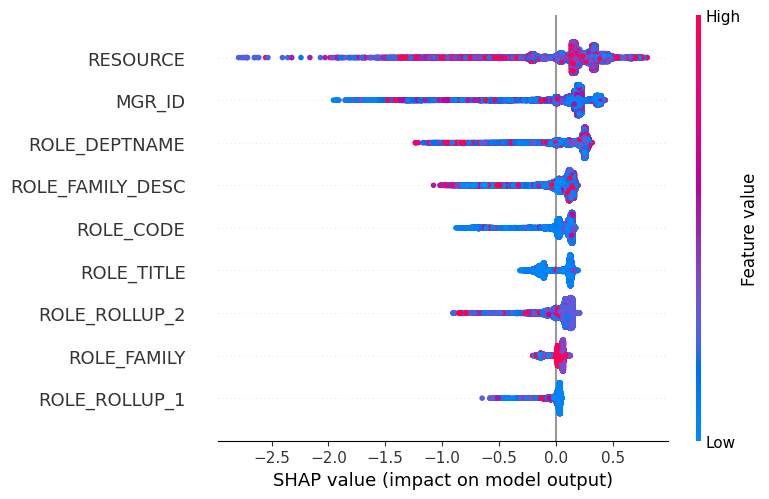

In [ ]:
shap.summary_plot(shap_values, X)

Shap-values для конкретного объекта.

In [ ]:
shap.initjs()
shap.force_plot(expected_value, shap_values[3, :], X.iloc[3, :])

Сохранение модели

In [ ]:
my_best_model = CatBoostClassifier(iterations=10)
my_best_model.fit(
    X_train,
    y_train,
    eval_set=(X_validation, y_validation),
    cat_features=cat_features,
    verbose=False,
)
my_best_model.save_model("catboost_model.bin")
my_best_model.save_model("catboost_model.json", format="json")

In [ ]:
my_best_model.load_model("catboost_model.bin")
print(my_best_model.get_params())
print(my_best_model.random_seed_)

{'iterations': 10, 'loss_function': 'Logloss', 'verbose': 0}
0


Подбор гиперпараметров

In [ ]:
cat = CatBoostClassifier(n_estimators=50)

grid = {"learning_rate": [0.03, 0.1], "depth": [4, 6, 10]}
#        'l2_leaf_reg': [1, 3, 5, 7, 9]}

grid_search_result = cat.grid_search(
    grid, X=X_train, y=y_train, verbose=False, plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6563183	test: 0.6566072	best: 0.6566072 (0)	total: 6.83ms	remaining: 335ms
1:	learn: 0.6227273	test: 0.6234014	best: 0.6234014 (1)	total: 12.6ms	remaining: 301ms
2:	learn: 0.5915555	test: 0.5927244	best: 0.5927244 (2)	total: 18.6ms	remaining: 292ms
3:	learn: 0.5626502	test: 0.5641488	best: 0.5641488 (3)	total: 24.6ms	remaining: 283ms
4:	learn: 0.5360501	test: 0.5378118	best: 0.5378118 (4)	total: 30.6ms	remaining: 275ms
5:	learn: 0.5116676	test: 0.5137107	best: 0.5137107 (5)	total: 36.4ms	remaining: 267ms
6:	learn: 0.4891782	test: 0.4914464	best: 0.4914464 (6)	total: 42.2ms	remaining: 259ms
7:	learn: 0.4684689	test: 0.4710067	best: 0.4710067 (7)	total: 48.1ms	remaining: 252ms
8:	learn: 0.4494887	test: 0.4523627	best: 0.4523627 (8)	total: 53.8ms	remaining: 245ms
9:	learn: 0.4317235	test: 0.4348204	best: 0.4348204 (9)	total: 59.7ms	remaining: 239ms
10:	learn: 0.4155907	test: 0.4189671	best: 0.4189671 (10)	total: 65.7ms	remaining: 233ms
11:	learn: 0.4007151	test: 0.4044185	best

In [ ]:
grid_search_result["params"]

{'depth': 10, 'learning_rate': 0.1}

Визуализация деревьев

In [ ]:
# Might run into the graphiz problem:
# https://stackoverflow.com/questions/35064304/runtimeerror-make-sure-the-graphviz-executables-are-on-your-systems-path-aft

In [ ]:
cat.plot_tree(tree_idx=0)

Хорошее описание гиперпараметров катбуста: https://habr.com/ru/company/otus/blog/527554/

## LightGBM

Особенности LightGBM:

* полиственное (leaf-wise), а не поуровневое (depth-wise) построение деревьев

* быстрое построение дерева, позволяющее не кодировать категориальные признаки, а использовать исходные категории для получения предикатов

* ускорение построения деревьев за счёт бинаризации признаков (объединение значений признака в группы)

Почитать подробнее можно тут: https://medium.com/@pushkarmandot/https-medium-com-pushkarmandot-what-is-lightgbm-how-to-implement-it-how-to-fine-tune-the-parameters-60347819b7fc

In [ ]:
# !conda install lightgbm --y

# For those who strugle with M1/M2 macs:
# !arch -arm64 brew install libomp

In [ ]:
import lightgbm as lgb
from lightgbm import early_stopping
#import numpy as np
#from sklearn.datasets import load_boston
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split

# data = load_boston()
# X_full = data.data
# y_full = data.target

# X_train, X_test, y_train, y_test = train_test_split(
#     X_full, y_full, test_size=100, random_state=241
# )

In [ ]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [ ]:
#data = load_boston()
X_full = data # data.data
y_full = target # data.target

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=100, random_state=241
)

Обучение

In [ ]:
print("Starting training...")
# train
gbm = lgb.LGBMRegressor(num_leaves=31, learning_rate=0.05, n_estimators=20)
gbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="l1",
    callbacks=[early_stopping(stopping_rounds=5)]
)

Starting training...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1030
[LightGBM] [Info] Number of data points in the train set: 406, number of used features: 13
[LightGBM] [Info] Start training from score 22.746305
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 5 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMRegressor(learning_rate=0.05, n_estimators=20)

Предсказание и оценка качества

In [ ]:
print("Starting predicting...")

y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)

print("The rmse of prediction is:", mean_squared_error(y_test, y_pred) ** 0.5)

# feature importances
print("Feature importances:", list(gbm.feature_importances_))

Starting predicting...
The rmse of prediction is: 5.259625962258064
Feature importances: [np.int32(35), np.int32(0), np.int32(6), np.int32(0), np.int32(20), np.int32(70), np.int32(21), np.int32(31), np.int32(3), np.int32(7), np.int32(15), np.int32(4), np.int32(83)]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Можно задать любую (придумать свою, например) метрику качества

In [ ]:
# self-defined eval metric
# f(y_true: array, y_pred: array) -> name: string, eval_result: float, is_higher_better: bool
# Root Mean Squared Logarithmic Error (RMSLE)
def rmsle(y_true, y_pred):
    return (
        "RMSLE",
        np.sqrt(np.mean(np.power(np.log1p(y_pred) - np.log1p(y_true), 2))),
        False,
    )


print("Starting training with custom eval function...")
# train
gbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=rmsle,
    callbacks=[early_stopping(stopping_rounds=5)]
)

print("Starting predicting...")
# predict
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)
# eval
print("The rmsle of prediction is:", rmsle(y_test, y_pred)[1])

Starting training with custom eval function...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1030
[LightGBM] [Info] Number of data points in the train set: 406, number of used features: 13
[LightGBM] [Info] Start training from score 22.746305
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 5 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Подбор гиперпараметров

In [ ]:
# other scikit-learn modules
estimator = lgb.LGBMRegressor(num_leaves=31)

param_grid = {"learning_rate": [0.01, 0.1, 1], "n_estimators": [20, 40]}

gbm = GridSearchCV(estimator, param_grid, cv=3)
gbm.fit(X_train, y_train)

print("Best parameters found by grid search are:", gbm.best_params_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 688
[LightGBM] [Info] Number of data points in the train set: 270, number of used features: 12
[LightGBM] [Info] Start training from score 22.805926
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 681
[LightGBM] [Info] Number of data points in the train set: 271, number of used features: 13
[LightGBM] [Info] Start training from score 22.491144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 688
[LightGBM] [Info] Number of data points in the train set: 270, number of used features: 12
[LightGBM] [Info] Start training from score 22.805926
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 688
[LightGBM] [Info] Number of data points in the train set: 270, number of used features: 12
[LightGBM] [Info] Start training from score 22.805926
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

Предсказание и оценка качества

In [ ]:
pred = gbm.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, pred)

12.703535974721541

# Bayesian optimization

In [ ]:
!pip install -q bayesian-optimization

In [ ]:
from catboost import CatBoostRegressor
from sklearn.datasets import load_diabetes
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt
import seaborn as sns


# Define the objective function for Bayesian Optimization
def catboost_cv(depth, learning_rate, iterations, subsample, l2_leaf_reg):
    # Convert hyperparameters to the right format
    depth = int(depth)
    iterations = int(iterations)
    l2_leaf_reg = int(l2_leaf_reg)
    # Initialize the CatBoost model (CatBoostRegressor for regression)
    model = CatBoostRegressor(
        depth=depth,
        learning_rate = float(learning_rate),
        iterations=iterations,
        subsample = float(subsample),
        l2_leaf_reg=l2_leaf_reg,
        verbose=False
    )

    # Perform cross-validation and return the mean R-squared score (for regression)
    cross_val_scores = cross_val_score(model, X, y, cv=3, scoring='r2')

    return cross_val_scores.mean()

# Define the hyperparameter search space with data types
param_space = {
    'depth': (3, 10),             # Integer values for depth
    'learning_rate': (0.01, 0.3),  # Float values for learning rate
    'iterations': (100, 1000),    # Integer values for iterations
    'subsample': (0.5, 1),       # Float values for subsample
    'l2_leaf_reg': (1, 10)        # Integer values for l2_leaf_reg
}

# Create the BayesianOptimization object and maximize it
bayesian_opt = BayesianOptimization(
    f=catboost_cv, pbounds=param_space, random_state=42)
bayesian_opt.maximize(init_points=5, n_iter=10)
results = pd.DataFrame(bayesian_opt.res)
results.sort_values(by='target', ascending=False, inplace=True)

# Print the best hyperparameters and their corresponding R2 score
best_hyperparameters = bayesian_opt.max
best_hyperparameters['params'] = {param: int(value) if param in [
    'depth', 'iterations', 'l2_leaf_reg'] else value for param, value in best_hyperparameters['params'].items()}
print("Best hyperparameters:", best_hyperparameters['params'])
print(f"Best R-squared Score: {best_hyperparameters['target']:.4f}")

|   iter    |  target   |   depth   | learni... | iterat... | subsample | l2_lea... |
-------------------------------------------------------------------------------------
| 1         | 0.1955178 | 5.6217808 | 0.2857071 | 758.79454 | 0.7993292 | 2.4041677 |
| 2         | 0.0843201 | 4.0919616 | 0.0268442 | 879.55853 | 0.8005575 | 7.3726532 |
| 3         | 0.1612734 | 3.1440914 | 0.2912738 | 849.19837 | 0.6061695 | 2.6364247 |
| 4         | 0.1355182 | 4.2838315 | 0.0982302 | 572.28078 | 0.7159725 | 3.6210622 |
| 5         | 0.1358404 | 7.2829702 | 0.0504532 | 362.93018 | 0.6831809 | 5.1046298 |
| 6         | 0.1981955 | 5.2507190 | 0.2678860 | 757.80800 | 0.7752354 | 2.4749791 |
| 7         | 0.1984274 | 10.0      | 0.3       | 740.01058 | 1.0       | 10.0      |
| 8         | 0.0364286 | 3.0       | 0.01      | 714.01234 | 0.5       | 1.0       |
| 9         | 0.1512555 | 4.7401813 | 0.0904784 | 818.79622 | 0.9376774 | 3.6844414 |
| 10        | 0.1375411 | 7.1116168 | 0.2119999 | 101.